<a href="https://colab.research.google.com/github/aryaraut13/100-days-of-aiml/blob/main/day%206-%20probability" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

P(fraud | flagged) = 15.5%


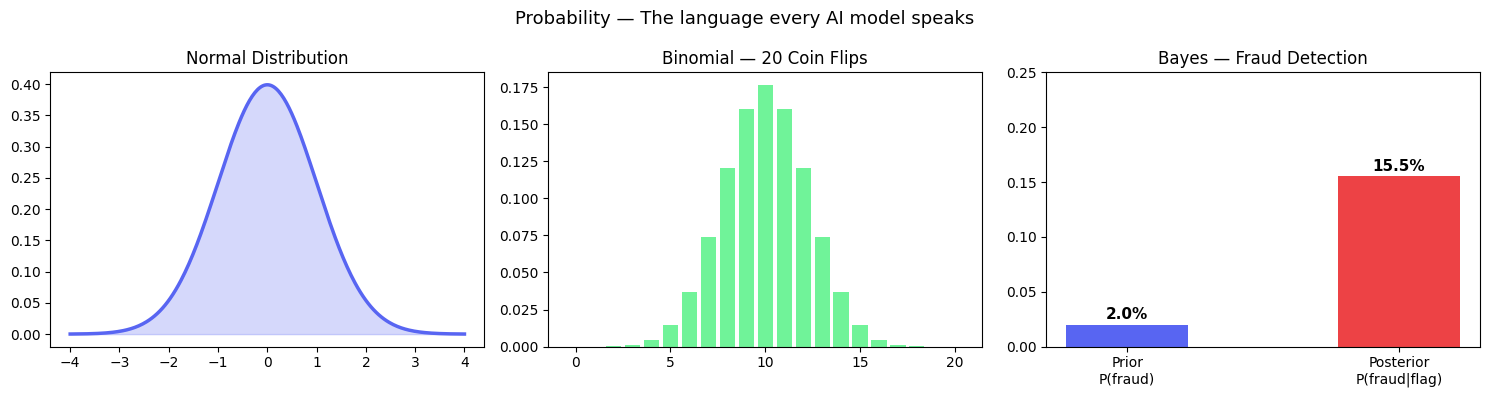

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, binom

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Probability — The language every AI model speaks", fontsize=13)

x = np.linspace(-4, 4, 300)
axes[0].plot(x, norm.pdf(x, 0, 1), "#5865F2", lw=2.5)
axes[0].fill_between(x, norm.pdf(x, 0, 1), alpha=0.25, color="#5865F2")
axes[0].set_title("Normal Distribution")

n, p = 20, 0.5
k = np.arange(0, n+1)
axes[1].bar(k, binom.pmf(k, n, p), color="#57F287", edgecolor="none", alpha=0.85)
axes[1].set_title("Binomial — 20 Coin Flips")

# Bayes: fraud detection example
p_fraud            = 0.02
p_flag_if_fraud    = 0.90
p_flag_if_legit    = 0.10

p_flag = p_flag_if_fraud*p_fraud + p_flag_if_legit*(1-p_fraud)
p_fraud_given_flag = (p_flag_if_fraud * p_fraud) / p_flag

print(f"P(fraud | flagged) = {p_fraud_given_flag:.1%}")
# → 15.5% — not 90%

labels = ["Prior\nP(fraud)", "Posterior\nP(fraud|flag)"]
values = [p_fraud, p_fraud_given_flag]
bars = axes[2].bar(labels, values, color=["#5865F2","#ED4245"], width=0.45)
axes[2].set_ylim(0, 0.25)
axes[2].set_title("Bayes — Fraud Detection")
for bar, v in zip(bars, values):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.005,
                 f"{v:.1%}", ha="center", fontweight="bold", fontsize=11)

plt.tight_layout()
plt.savefig("day06_probability.png", dpi=150)
plt.show()